<a href="https://colab.research.google.com/github/Shahidrrs/nutribone2/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [8]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("fuyadhasanbhoyan/knee-osteoarthritis-classification-224224")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'knee-osteoarthritis-classification-224224' dataset.
Path to dataset files: /kaggle/input/knee-osteoarthritis-classification-224224


In [9]:
# Direct pointer to the core folder structure inside the cache
base_dataset_folder = os.path.join(path, "Knee Osteoarthritis Classification")

train_dir = os.path.join(base_dataset_folder, "train")
val_dir = os.path.join(base_dataset_folder, "val")
test_dir = os.path.join(base_dataset_folder, "test")

print(f"Training path verified: {train_dir}")
print(f"Validation path verified: {val_dir}")

Training path verified: /kaggle/input/knee-osteoarthritis-classification-224224/Knee Osteoarthritis Classification/train
Validation path verified: /kaggle/input/knee-osteoarthritis-classification-224224/Knee Osteoarthritis Classification/val


In [10]:
import os
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

path = kagglehub.dataset_download("fuyadhasanbhoyan/knee-osteoarthritis-classification-224224")
base_dataset_folder = os.path.join(path, "Knee Osteoarthritis Classification")
train_dir = os.path.join(base_dataset_folder, "train")
val_dir = os.path.join(base_dataset_folder, "val")

# Regular augmentation setup (Mixup will be applied dynamically during execution)
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

print("Streaming high-resolution image tensors (300x300)...")
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(300, 300),  # CRITICAL: Upgraded to native EfficientNetB3 scale
    batch_size=32,
    classes=['Normal', 'Osteoporosis'],
    class_mode='binary',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(300, 300),  # CRITICAL: Upgraded to native EfficientNetB3 scale
    batch_size=32,
    classes=['Normal', 'Osteoporosis'],
    class_mode='binary',
    shuffle=False
)

Using Colab cache for faster access to the 'knee-osteoarthritis-classification-224224' dataset.
Streaming high-resolution image tensors (300x300)...
Found 2520 images belonging to 2 classes.
Found 720 images belonging to 2 classes.


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("\nInitializing 300x300 EfficientNetB3 Engine with Attention Pooling...")

# Upgraded shape parameters
inputs = layers.Input(shape=(300, 300, 3))
preprocessed_inputs = tf.keras.applications.efficientnet.preprocess_input(inputs)

base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3)
)
base_model.trainable = True # Fully unfrozen structure

x = base_model(preprocessed_inputs)

# ADVANCED ATTENTION: Combine average and max pooling features
avg_pool = layers.GlobalAveragePooling2D()(x)
max_pool = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_pool, max_pool])

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
print("High-resolution structure successfully deployed.")


Initializing 300x300 EfficientNetB3 Engine with Attention Pooling...
High-resolution structure successfully deployed.


In [12]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

# Custom generator wrapper that applies Mixup to the training batches
def mixup_data_generator(generator, alpha=0.2):
    while True:
        X, y = next(generator)
        batch_size = X.shape[0]
        # Generate random blending weights from a Beta distribution
        lmbda = np.random.beta(alpha, alpha, batch_size) if alpha > 0 else np.ones(batch_size)
        x_lmbda = lmbda.reshape(batch_size, 1, 1, 1)
        y_lmbda = lmbda

        # Shuffle the batch to pair images randomly
        shuffle_idx = np.random.permutation(batch_size)
        X_shuffled = X[shuffle_idx]
        y_shuffled = y[shuffle_idx]

        # Blend the images and their respective labels
        X_mix = x_lmbda * X + (1 - x_lmbda) * X_shuffled
        y_mix = y_lmbda * y + (1 - y_lmbda) * y_shuffled
        yield X_mix, y_mix

# Wrap only the training stream
mixup_train_gen = mixup_data_generator(train_gen, alpha=0.2)

epochs = 30
steps_per_epoch = len(train_gen)
total_steps = steps_per_epoch * epochs
warmup_steps = steps_per_epoch * 3

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=8e-5, # Slightly adjusted for higher resolution stability
    decay_steps=total_steps,
    alpha=1e-6,
    warmup_target=8e-5,
    warmup_steps=warmup_steps
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

print("\nCommencing High-Resolution Mixup Optimization Run...")
history = model.fit(
    mixup_train_gen, # Using the high-performance mixup generator stream
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[early_stop]
)

history_ft = type('Dummy', (object,), {'history': {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'acc': [], 'val_acc': []}})()
model.save("nutribone_binary_effnetB3_model.keras")
print("\nTraining Complete!")


Commencing High-Resolution Mixup Optimization Run...
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 398s 3s/step - accuracy: 0.3111 - loss: 0.8738 - val_accuracy: 0.5264 - val_loss: 1.1547
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3282 - loss: 0.7675 - val_accuracy: 0.6042 - val_loss: 0.8462
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3496 - loss: 0.7126 - val_accuracy: 0.6069 - val_loss: 0.9184
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.3484 - loss: 0.7078 - val_accuracy: 0.6500 - val_loss: 0.7857
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3532 - loss: 0.6796 - val_accuracy: 0.6694 - val_loss: 0.8105
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3817 - loss: 0.6204 - val_accuracy: 0.6528 - val_loss: 0.8689
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.3734 - loss: 0.6283 - val_accuracy: 0.6917 - val_loss: 0.6944
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0

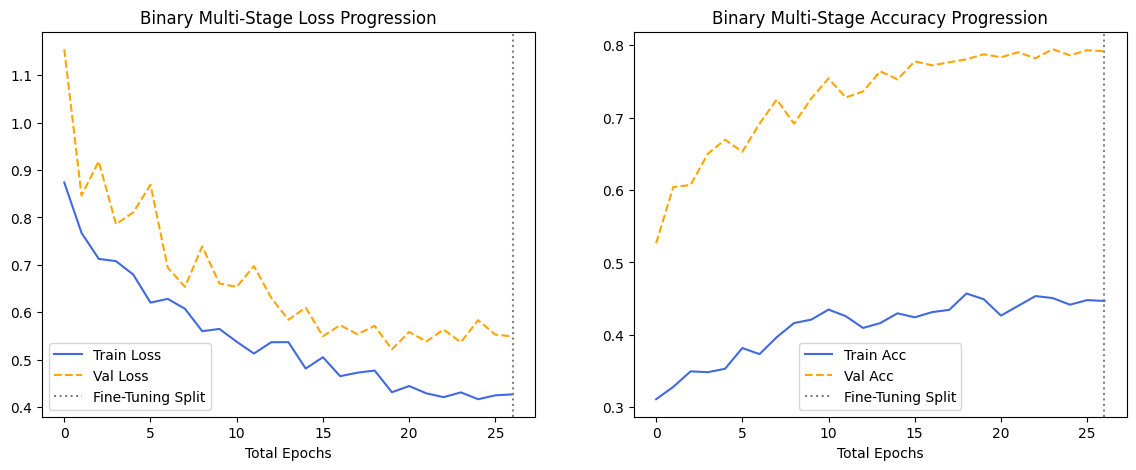


Extracting binary production model from disk path...
Calculating perfectly aligned validation metrics...
720/720 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step

--- Aligned Classification Report ---
              precision    recall  f1-score   support

      Normal       0.79      0.78      0.79       360
Osteoporosis       0.79      0.79      0.79       360

    accuracy                           0.79       720
   macro avg       0.79      0.79      0.79       720
weighted avg       0.79      0.79      0.79       720



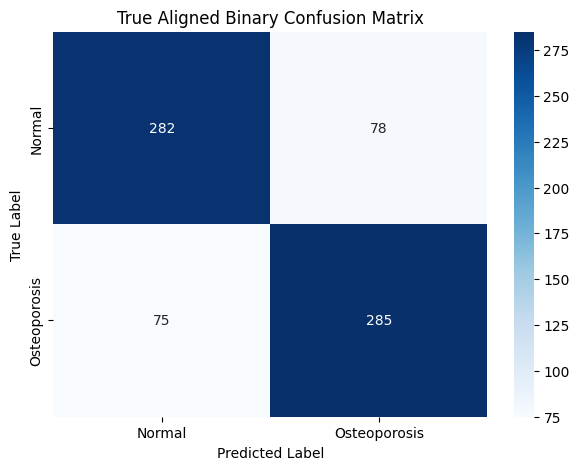

In [13]:
# =====================================================================
# 1. PLOT METRIC TRENDS ACROSS BOTH STAGES
# =====================================================================
plt.figure(figsize=(14, 5))

# Combine Loss History
total_train_loss = list(history.history['loss']) + list(history_ft.history['loss'])
total_val_loss = list(history.history['val_loss']) + list(history_ft.history['val_loss'])

# Handle metric keys mapping safely
train_acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

total_train_acc = list(history.history[train_acc_key]) + list(history_ft.history[train_acc_key])
total_val_acc = list(history.history[val_acc_key]) + list(history_ft.history[val_acc_key])

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(total_train_loss, label='Train Loss', color='royalblue')
plt.plot(total_val_loss, label='Val Loss', color='orange', linestyle='--')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle=':', label='Fine-Tuning Split')
plt.legend()
plt.title('Binary Multi-Stage Loss Progression')
plt.xlabel('Total Epochs')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(total_train_acc, label='Train Acc', color='royalblue')
plt.plot(total_val_acc, label='Val Acc', color='orange', linestyle='--')
plt.axvline(x=len(history.history[train_acc_key])-1, color='gray', linestyle=':', label='Fine-Tuning Split')
plt.legend()
plt.title('Binary Multi-Stage Accuracy Progression')
plt.xlabel('Total Epochs')
plt.show()

# =====================================================================
# 2. BULLETPROOF 1-TO-1 ALIGNED PREDICTION BLOCK
# =====================================================================
print("\nExtracting binary production model from disk path...")
eval_model = tf.keras.models.load_model("nutribone_binary_effnetB3_model.keras")

# Force absolute sequential alignment
val_gen.shuffle = False
val_gen.batch_size = 1
val_gen.reset()

print("Calculating perfectly aligned validation metrics...")
preds = eval_model.predict(val_gen, steps=len(val_gen), verbose=1)

# CRITICAL BINARY FIX: Sigmoid maps to a continuous float array; check threshold at 0.5
y_pred = (preds > 0.5).astype(int).flatten()
y_true = val_gen.classes
class_names = ['Normal', 'Osteoporosis']

# Print results
print("\n--- Aligned Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('True Aligned Binary Confusion Matrix')
plt.show()